<font size="5">

## VIVA Q&A
    
1. What is a Seasonal Index?
Answer: It is a percentage that shows how much a specific month is "above average" or "below average" purely because of the time of year. (For example, an index of 120 means that month is historically 20% busier than normal).

2. What is a Link Relative (LR)?
Answer: It is a percentage that compares a month's data only to the month immediately before it. (For example: dividing March’s sales by February’s sales). It links next-door neighbors.

3. What is a Chain Relative (CR)?
Answer: It is a percentage that connects all the months back to a single starting line (Usually January = 100). It takes the individual links and chains them together so you can see the whole year.

4. Why do we drop the very first month (use .dropna()) when calculating Link Relatives?
Answer: Because the very first month in the dataset (like Jan 1949) has no previous month to divide by. If we don't drop it, the computer will crash trying to divide by a blank value.

5. Why do we need a "Trend Correction Factor" (the d variable)?
Answer: Because businesses naturally grow over a year. By the time we chain our numbers from January to December, the numbers are artificially inflated by that growth. The correction factor mathematically subtracts that upward growth so we only see the pure seasonal spikes.

6. Why do we divide the Chain Relatives by their average at the very end?
Answer: Because the 12 final seasonal indices must perfectly add up to exactly 1200 (since a perfectly average year without seasons is 100 per month). Dividing by the average balances the scale perfectly.

7. Why use the Link Relative method instead of a Moving Average?
Answer: Because instead of creating a smooth, long-term trend line, the Link Relative method compares every single month directly to its neighbor. This makes it highly sensitive to sudden, short-term shifts in the data.

</font>

--- Practical: Seasonal Indices by Link Relative Method ---
Loading 'flights' dataset...

--- Link Relative Computations & Final Indices ---
Month  Average LR  Chain Relative  Adjusted CR  Seasonal Index
  Jan      102.57          100.00       100.00           90.36
  Feb       98.95           98.95        97.87           88.43
  Mar      115.17          113.97       111.79          101.01
  Apr       97.99          111.68       108.42           97.97
  May      100.86          112.64       108.29           97.85
  Jun      114.25          128.70       123.25          111.37
  Jul      112.12          144.30       137.77          124.48
  Aug      100.11          144.46       136.84          123.65
  Sep       87.49          126.39       117.69          106.34
  Oct       88.00          111.23       101.43           91.65
  Nov       87.51           97.33        86.45           78.11
  Dec      113.25          110.22        98.25           88.78

Sum of Seasonal Indices: 1200.00 (Shoul

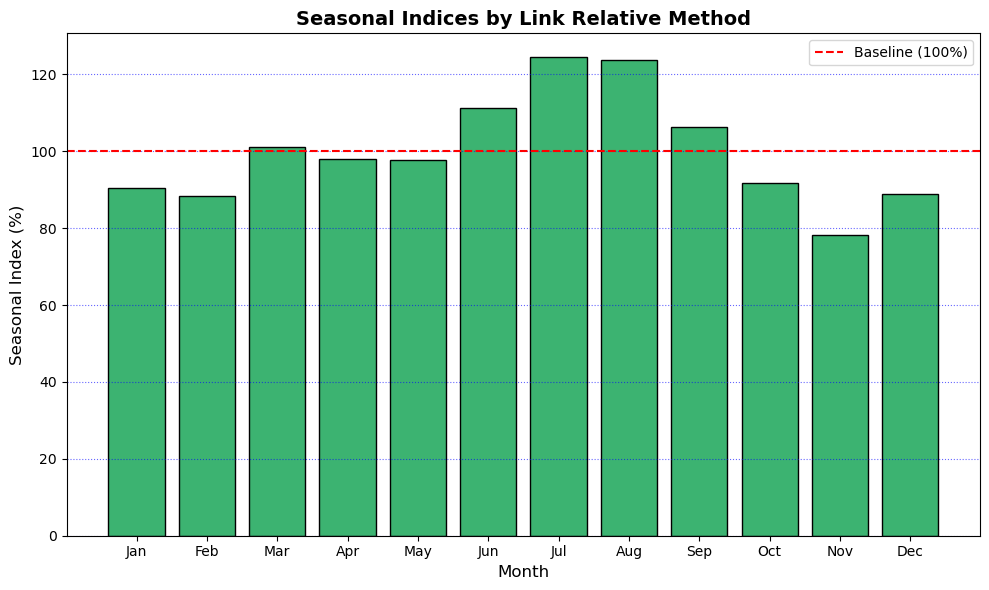

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

def calculate_link_relative():
    print("--- Practical: Seasonal Indices by Link Relative Method ---")
    
    # 1. Load the Dataset
    print("Loading 'flights' dataset...")
    df = sns.load_dataset('flights')
    
    # 2. Calculate Link Relatives (LR)
    # Formula: (Current Month / Previous Month) * 100
    df['Link_Relative'] = (df['passengers'] / df['passengers'].shift(1)) * 100
    
    # 3. Calculate Average Link Relative for each specific month
    # We use .dropna() because the very first month (Jan 1949) has no previous month to divide by.
    mean_lr = df.dropna().groupby('month')['Link_Relative'].mean()
    
    # 4. Calculate Chain Relatives (CR)
    # The CR of the first month (January) is always assumed to be 100.
    cr = np.zeros(12)
    cr[0] = 100.0
    
    # Calculate CR for Feb through Dec
    # Formula: (Current Month's Mean LR * Previous Month's CR) / 100
    for i in range(1, 12):
        cr[i] = (mean_lr.iloc[i] * cr[i-1]) / 100.0
        
    # 5. Trend Correction Factor
    # We must calculate a "new" January CR based on December's CR to find the mathematical error (trend bias).
    new_cr_jan = (mean_lr.iloc[0] * cr[11]) / 100.0
    
    # The difference between the new Jan CR and 100, divided by 12, gives the monthly adjustment factor (d)
    d = (new_cr_jan - 100.0) / 12.0
    
    # Apply the correction: Adjusted CR = Original CR - (month_index * d)
    adjusted_cr = np.zeros(12)
    for i in range(12):
        adjusted_cr[i] = cr[i] - (i * d)
        
    # 6. Calculate Final Seasonal Indices
    # The average of the Adjusted CRs is our baseline. 
    # We adjust everything proportionally so the final indices sum perfectly to 1200 (100 * 12).
    average_adjusted_cr = np.mean(adjusted_cr)
    seasonal_indices = (adjusted_cr / average_adjusted_cr) * 100.0
    
    # 7. Combine results into a neat display table
    results_df = pd.DataFrame({
        'Month': mean_lr.index,
        'Average LR': mean_lr.values,
        'Chain Relative': cr,
        'Adjusted CR': adjusted_cr,
        'Seasonal Index': seasonal_indices
    }).round(2)
    
    print("\n--- Link Relative Computations & Final Indices ---")
    print(results_df.to_string(index=False))
    print(f"\nSum of Seasonal Indices: {seasonal_indices.sum():.2f} (Should be perfectly 1200.00)")

    # 8. Plotting the Results
    plt.figure(figsize=(10, 6))
    
    # Bar chart for Seasonal Indices
    plt.bar(results_df['Month'], results_df['Seasonal Index'], color='mediumseagreen', edgecolor='black')
    plt.axhline(y=100, color='red', linestyle='--', label='Baseline (100%)')
    
    plt.title('Seasonal Indices by Link Relative Method', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Seasonal Index (%)', fontsize=12)
    plt.legend()
    plt.grid(True, axis='y', linestyle=':', alpha=0.6,color="blue")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    calculate_link_relative()

## The Core Mathematical Code Explanation 


### Block #1: Calculating the "Month-to-Month" Jumps

```python
df["link_relative"] = (df["passengers"]/df["passengers"].shift(1))*100.0

```

**What this does:** It calculates the "Link Relative" (LR). It looks at how much passenger traffic jumped or dropped compared to the month *immediately before it*.

* **`df["passengers"]`**: The current month's passengers (e.g., February).
* **`df["passengers"].shift(1)`**: The computer grabs the passenger column and shifts it down by 1 row. This acts as the *previous* month (e.g., January).
* **Why multiply by `100.0`?** To turn the decimal into a clean percentage.

**How it looks in the data table:**

| Month | Passengers | Shift(1) (Previous) | Math (Current / Previous * 100) | Result (Link Relative) |
| --- | --- | --- | --- | --- |
| Jan 1949 | 100 | *Empty (NaN)* | `100 / NaN` | **NaN** (Blank) |
| Feb 1949 | 110 | 100 | `110 / 100 * 100` | **110.0** |
| Mar 1949 | 132 | 110 | `132 / 110 * 100` | **120.0** |

---

### Block #2: Averaging the Jumps to Kill the "Noise"

```python
mean_lr = df.dropna().groupby("month")["link_relative"].mean()

```

**What this does:** It looks at 12 years of history, groups all identical months together, and finds their average jump.

* **`.dropna()`**: Drops the very first row (Jan 1949) because it has a blank `NaN` value (since there was no December 1948 to divide it by). If you don't drop it, the math crashes.
* **`.groupby("month")`**: Sorts all 144 rows into 12 neat piles (All Januaries in one pile, all Februaries in another).
* **`.mean()`**: Calculates the historical average for each pile.

**How it looks (A simple list of 12 numbers):**

* **Jan:** 102.5
* **Feb:** 101.2
* **Mar:** 115.0 ... *(This means March is historically 115% of February)*

---

### Block #3: Chaining the Links Together

```python
cr = np.zeros(12)
cr[0] = 100.0
for i in range(1,12):
    cr[i] = (mean_lr.iloc[i]*cr[i-1])/100.0

```

**What this does:** It calculates the "Chain Relative" (CR). It connects every month back to a single starting line (January) so we can see the whole year's progression.

* **`np.zeros(12)`**: Creates 12 empty buckets filled with zeros `[0., 0., 0., ...]`
* **`cr[0] = 100.0`**: We force the first bucket (January) to be our baseline of 100. `[100., 0., 0., ...]`
* **`for i in range(1,12):`**: A loop that travels from bucket index 1 (Feb) to 11 (Dec).
* **`cr[i] = ...`**: To fill February's bucket, it multiplies February's average link (`mean_lr.iloc[1]`) by January's chain (`cr[0]`), and divides by 100. Then it does March based on February, and so on.

---

### Block #4: The Trend Correction (⚠️ IMPORTANT FIX HERE)

```python
new_adjusted_cr = (mean_lr.iloc[0]*cr[11])/100.0
d = (new_adjusted_cr - 100.0) / 12.0   # <--- YOU MUST ADD THESE PARENTHESES!
adjusted_cr = np.zeros(12)
for i in range(12):
    adjusted_cr[i] = cr[i] - (i*d)

```

**What this does:** It removes the natural long-term business growth (trend) that inflated our chain.

* **`new_adjusted_cr = ...`**: We use December's chain (`cr[11]`) and January's link (`mean_lr.iloc[0]`) to calculate a "New January" for the next year.
* **`d = (new_adjusted_cr - 100.0) / 12.0`**:
* *Why the parentheses?* Without them, Python divides 100 by 12 *first* (BODMAS rules). You must wrap the subtraction in parentheses to find the total error *before* dividing by 12!
* This calculates `d` (the tiny bit of trend growth that snuck into each month).


* **`adjusted_cr = np.zeros(12)`**: Creates 12 new empty buckets for our corrected numbers.
* **`adjusted_cr[i] = cr[i] - (i*d)`**: The loop subtracts the trend.
* Jan (`i=0`): Subtracts `0 * d` (Jan is untouched).
* Feb (`i=1`): Subtracts `1 * d`.
* Dec (`i=11`): Subtracts `11 * d`.



---

### Block #5: Balancing the Final Scales

```python
av_adjusted_cr = np.mean(adjusted_cr)
seasonal_indices = (adjusted_cr/av_adjusted_cr)*100.0

```

**What this does:** It makes sure the 12 final seasonal indices perfectly balance out to equal 1200 (an average of 100 per month).

* **`av_adjusted_cr = np.mean(adjusted_cr)`**: Calculates the overall average of our 12 corrected chain relatives. (e.g., maybe it averages to 101.5 instead of perfectly 100).
* **`(adjusted_cr/av_adjusted_cr)*100.0`**: We take each month's score, divide it by that imperfect average, and multiply by 100.

**How it looks (The Final Output):**
This scales every number slightly so that if you add all 12 of them up, they will equal **exactly 1200.00**. These are your final pure seasonal percentages!